<a href="https://colab.research.google.com/github/anika-tabassum-10/SICIP-ML_DL-Projects/blob/colab-notebooks/1000129232_SICIP_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Medical Image Classification with a CNN**

This notebook builds, trains and evaluates a Convolutional Neural Network (CNN) that classifies chest X-ray images as Normal or Pneumonia.

**Dataset**: PneumoniaMNIST - a standardized, publicly available medical imaging benchmark distributed via the medmnist Python package. It is derived from the Kaggle Chest X-Ray Images (Pneumonia) dataset (Kermany et al.).

**Source:** MedMNIST v2 benchmark (built from the Kaggle Chest X-Ray Images (Pneumonia) dataset).

**Task:** Binary classification - Normal vs Pneumonia.

In [10]:
!pip install medmnist -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.transforms as transforms

import medmnist
from medmnist import PneumoniaMNIST, INFO

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [11]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"medmnist version: {medmnist.__version__}")


Using device: cpu
medmnist version: 3.0.2


In [12]:
IMG_SIZE = 64
BATCH_SIZE = 64

info = INFO['pneumoniamnist']
class_names = [info['label'][str(i)].capitalize() for i in range(len(info['label']))]
print("Task type:", info['task'])
print("Classes:", class_names)

mean, std = (0.5,), (0.5,)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = PneumoniaMNIST(split='train', transform=train_transform, download=True, size=IMG_SIZE)
val_dataset   = PneumoniaMNIST(split='val',   transform=eval_transform,  download=True, size=IMG_SIZE)
test_dataset  = PneumoniaMNIST(split='test',  transform=eval_transform,  download=True, size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images | Test: {len(test_dataset)} images")

Task type: binary-class
Classes: ['Normal', 'Pneumonia']
Train: 4708 images | Val: 524 images | Test: 624 images


**Exploratory Data Analysis (EDA)**

Class distribution (Train): {'Pneumonia': 3494, 'Normal': 1214}
Class distribution (Val):   {'Pneumonia': 389, 'Normal': 135}
Class distribution (Test):  {'Pneumonia': 390, 'Normal': 234}


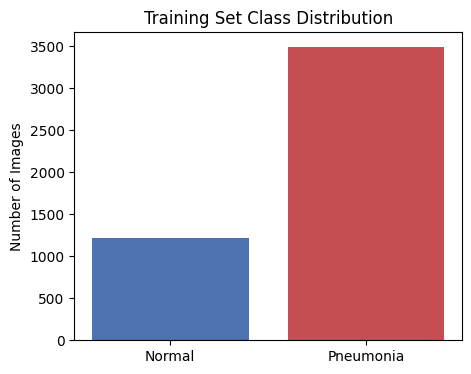

In [13]:
def get_label_counts(dataset):
    labels = dataset.labels.squeeze()
    return Counter(labels.tolist())

train_counts = get_label_counts(train_dataset)
val_counts   = get_label_counts(val_dataset)
test_counts  = get_label_counts(test_dataset)

print("Class distribution (Train):", {class_names[k]: v for k, v in train_counts.items()})
print("Class distribution (Val):  ", {class_names[k]: v for k, v in val_counts.items()})
print("Class distribution (Test): ", {class_names[k]: v for k, v in test_counts.items()})

plt.figure(figsize=(5, 4))
plt.bar(class_names, [train_counts[i] for i in range(len(class_names))],
        color=['#4C72B0', '#C44E52'])
plt.title('Training Set Class Distribution')
plt.ylabel('Number of Images')
plt.show()

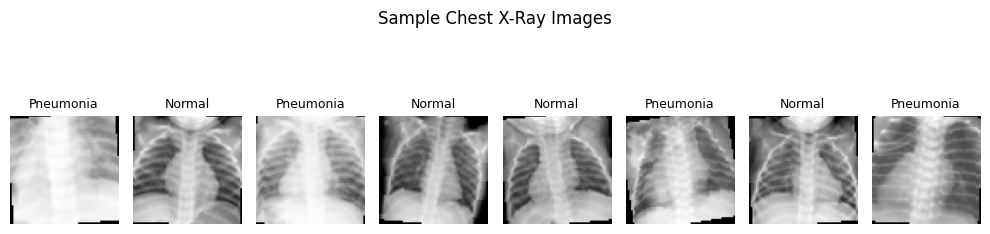

In [14]:
def unnormalize(img_tensor):
    return img_tensor / 2.0 + 0.5

data_iter = iter(train_loader)
sample_images, sample_labels = next(data_iter)
sample_labels = sample_labels.squeeze()

plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    img = unnormalize(sample_images[i])
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    plt.title(class_names[sample_labels[i].item()], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Chest X-Ray Images')
plt.tight_layout()
plt.show()

**CNN Architechture - Residual Blocks**

**Architecture:**
* **Stem:** `Conv(1→32, 3×3) → BatchNorm → ReLU → MaxPool` — initial low-level feature extraction, `64×64 → 32×32`
* **Residual Stage 1:** `ResidualBlock(32→64, stride=2)` — `32×32 → 16×16`
* **Residual Stage 2:** `ResidualBlock(64→128, stride=2)` — `16×16 → 8×8`
* **Residual Stage 3:** `ResidualBlock(128→256, stride=2)` — `8×8 → 4×4`
* **Global Average Pooling:** `4×4 → 1×1` (reduces spatial size without a huge, overfitting-prone flatten layer)
* **Dropout(0.4)** — regularization before the final layer
* **Fully Connected:** `256 → 2` (logits for Normal / Pneumonia)

Each `ResidualBlock` uses a `1×1` convolution "projection shortcut" whenever the spatial size or channel count changes between input and output, so the identity path can still be added elementwise - this mirrors the shortcut mechanism described for standard ResNet blocks.

In [15]:
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)


        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity
        out = self.relu(out)
        return out


class MedicalCNN(nn.Module):
    def __init__(self, num_classes=2, in_channels=1):
        super(MedicalCNN, self).__init__()

        # Stem: initial feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 64x64 -> 32x32
        )

        # Residual stages: progressively deeper channels, smaller spatial size
        self.layer1 = ResidualBlock(32, 64, stride=2)     # 32x32 -> 16x16
        self.layer2 = ResidualBlock(64, 128, stride=2)    # 16x16 -> 8x8
        self.layer3 = ResidualBlock(128, 256, stride=2)   # 8x8 -> 4x4

        self.global_pool = nn.AdaptiveAvgPool2d(1)        # 4x4 -> 1x1
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


model = MedicalCNN(num_classes=2, in_channels=1).to(device)
print(model)


MedicalCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(64, 

In [16]:
dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)

print("Step-by-step tensor dimensions:")
x = dummy_input
print(f"0. Input:         {list(x.shape)}")
x = model.stem(x);        print(f"1. After stem:    {list(x.shape)}")
x = model.layer1(x);      print(f"2. After layer1:  {list(x.shape)}")
x = model.layer2(x);      print(f"3. After layer2:  {list(x.shape)}")
x = model.layer3(x);      print(f"4. After layer3:  {list(x.shape)}")
x = model.global_pool(x); print(f"5. After pooling: {list(x.shape)}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Step-by-step tensor dimensions:
0. Input:         [1, 1, 64, 64]
1. After stem:    [1, 32, 32, 32]
2. After layer1:  [1, 64, 16, 16]
3. After layer2:  [1, 128, 8, 8]
4. After layer3:  [1, 256, 4, 4]
5. After pooling: [1, 256, 1, 1]

Total parameters:     1,207,778
Trainable parameters: 1,207,778


**Training, Validation & Checkpoints**

**Loss:** nn.CrossEntropyLoss(), weighted by inverse class frequency to counteract the class imbalance seen in the EDA step (there are more pneumonia than normal images).

**Optimizer:** Adam with lr=1e-3 and weight_decay=1e-4 (L2 regularization).
LR Scheduler: ReduceLROnPlateau, which halves the learning rate if validation loss stops improving.

**Checkpointing**: the model weights are saved to best_medical_cnn.pt whenever validation loss reaches a new minimum, so the final evaluation uses the best-performing weights rather than the last epoch's.

In [17]:
total_train = sum(train_counts.values())
num_classes = len(train_counts)
class_weights = torch.tensor(
    [total_train / (num_classes * train_counts[i]) for i in range(num_classes)],
    dtype=torch.float32
).to(device)
print("Class weights:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 15
best_val_loss = float('inf')

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # ---------------- Training ----------------
    model.train()
    running_loss, correct, total_samples = 0.0, 0, 0

    for inputs, targets in train_loader:
        targets = targets.squeeze().long()
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == targets).sum().item()
        total_samples += targets.size(0)

    train_loss = running_loss / total_samples
    train_acc = 100 * correct / total_samples

    # ---------------- Validation ----------------
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            targets = targets.squeeze().long()
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total
    scheduler.step(val_loss)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accuracies.append(train_acc); val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:5.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:5.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_medical_cnn.pt')
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")

Class weights: [1.9390445 0.6737264]
Epoch [ 1/15] Train Loss: 0.2055 Acc: 91.61% | Val Loss: 0.1605 Acc: 91.79%
  -> New best model saved (val_loss=0.1605)
Epoch [ 2/15] Train Loss: 0.1428 Acc: 94.46% | Val Loss: 0.1353 Acc: 95.80%
  -> New best model saved (val_loss=0.1353)
Epoch [ 3/15] Train Loss: 0.1147 Acc: 95.60% | Val Loss: 0.1169 Acc: 95.04%
  -> New best model saved (val_loss=0.1169)
Epoch [ 4/15] Train Loss: 0.1021 Acc: 95.75% | Val Loss: 0.1744 Acc: 90.27%
Epoch [ 5/15] Train Loss: 0.1028 Acc: 95.86% | Val Loss: 0.1971 Acc: 94.85%
Epoch [ 6/15] Train Loss: 0.0865 Acc: 96.58% | Val Loss: 0.0752 Acc: 97.52%
  -> New best model saved (val_loss=0.0752)
Epoch [ 7/15] Train Loss: 0.0888 Acc: 96.71% | Val Loss: 0.0890 Acc: 96.37%
Epoch [ 8/15] Train Loss: 0.0840 Acc: 96.71% | Val Loss: 0.0856 Acc: 96.56%
Epoch [ 9/15] Train Loss: 0.0771 Acc: 96.96% | Val Loss: 0.0672 Acc: 96.95%
  -> New best model saved (val_loss=0.0672)
Epoch [10/15] Train Loss: 0.0728 Acc: 97.05% | Val Loss: 0.

**Training Curves**

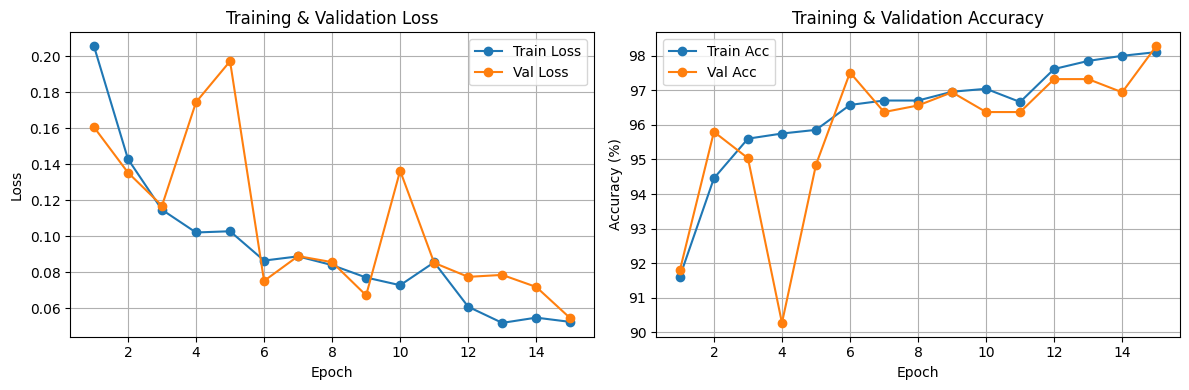

In [18]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

# Subplot 1: Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc', marker='o')
plt.plot(epochs_range, val_accuracies, label='Val Acc', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Test Set Evaluation**

In [19]:
model.load_state_dict(torch.load('best_medical_cnn.pt'))
model.eval()

all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        targets = targets.squeeze().long()
        inputs = inputs.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

test_accuracy = 100 * np.mean(all_preds == all_targets)
print(f"Test Accuracy: {test_accuracy:.2f}%\n")

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names))


Test Accuracy: 86.70%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.65      0.79       234
   Pneumonia       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.91      0.82      0.85       624
weighted avg       0.89      0.87      0.86       624



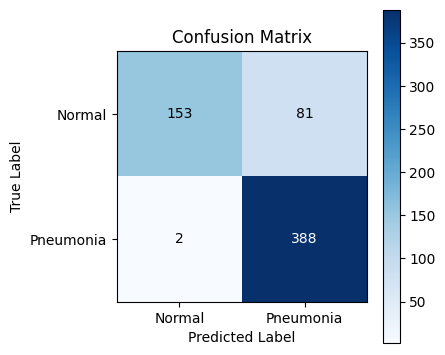

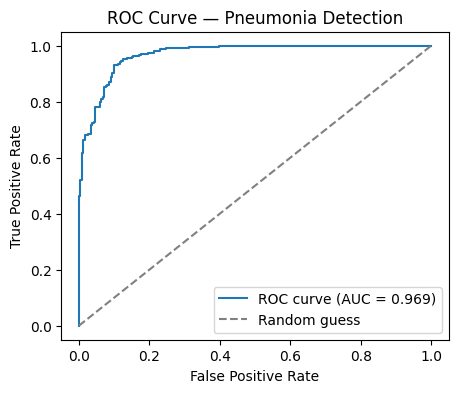

In [20]:
# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC curve & AUC
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Pneumonia Detection')
plt.legend(loc='lower right')
plt.show()


**Prediction Visualization**

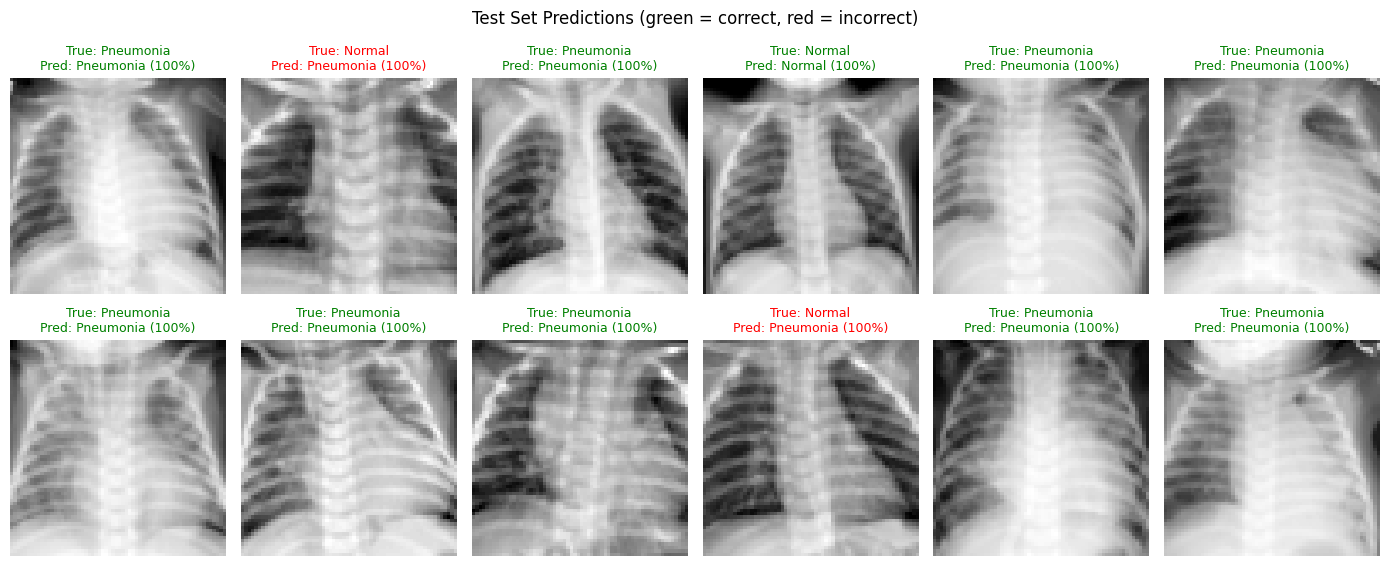

In [21]:
data_iter = iter(test_loader)
images, targets = next(data_iter)
targets = targets.squeeze().long()
images_gpu = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_gpu)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(outputs, dim=1).cpu()

plt.figure(figsize=(14, 6))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    img = unnormalize(images[i])
    plt.imshow(img.squeeze().numpy(), cmap='gray')

    true_label = class_names[targets[i].item()]
    pred_label = class_names[preds[i].item()]
    confidence = probs[i, preds[i]].item() * 100
    color = 'green' if preds[i] == targets[i] else 'red'

    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Test Set Predictions (green = correct, red = incorrect)')
plt.tight_layout()
plt.show()
